In [5]:
# Cell 1: 导入必要的库
import collections
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

# 确保结果的可复现性
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

# 设定设备：如果有 GPU / MPS（如 Mac 系列芯片）则加速计算
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print(f"当前使用的设备: {device}")

当前使用的设备: cuda


In [6]:
# Cell 2: 定义经验回放池
class ReplayBuffer:
    def __init__(self, capacity: int):
        # 使用双端队列，达到最大容量时会自动弹出最早的经验
        self.buffer = collections.deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        """将一条 transition 存入 buffer"""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size: int):
        """随机采样一个 batch 的数据用于训练"""
        transitions = random.sample(self.buffer, batch_size)
        # 将数据解耦并堆叠成 numpy 数组，方便后续转为 Tensor
        state, action, reward, next_state, done = zip(*transitions)
        return (
            np.array(state), 
            np.array(action), 
            np.array(reward), 
            np.array(next_state), 
            np.array(done)
        )

    def size(self):
        return len(self.buffer)

In [7]:
# Cell 3: 定义多层感知机 (MLP) 作为 Q 网络
class QNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super(QNetwork, self).__init__()
        # 简单的三层全连接网络
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)  # 输出所有动作的 Q 值

对于每一步 (Step)，执行以下操作：
1. **选择动作**：根据当前 Epsilon 选择动作（探索或贪婪）。
2. **执行动作**：与环境交互，获取奖励和新状态。
3. **存入经验**：将数据 `(s, a, r, s', done)` 存入 Buffer。
4. **模型更新**（如果 Buffer 数据量足够）：
   - 从 Buffer 中采样，更新 Policy 网络。
   - **同步 Target 网络**：如果更新次数是 N 的倍数（例如 200），则进行同步。
5. **探索度衰减**：Epsilon 衰减一点点。

一般都是按照 **Step (步数)** 进行探索度 `epsilon` 的线性衰减。

In [ ]:
# Cell 4: 定义 DQN 智能体
class DQNAgent:
    def __init__(self, state_dim, action_dim, learning_rate, gamma, epsilon_start, epsilon_end, epsilon_decay, target_update_freq):
        self.action_dim = action_dim
        self.gamma = gamma  # 折扣因子
        
        # epsilon-greedy 策略参数
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        self.target_update_freq = target_update_freq
        self.update_count = 0  # 记录网络更新次数
        
        # 实例化策略网络(Policy Net)和目标网络(Target Net)
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        # 初始化时，目标网络权重与策略网络一致
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)

    def take_action(self, state):
        """采用 epsilon-greedy 策略选择动作"""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)
        else:
            state_tensor = torch.tensor(np.array([state]), dtype=torch.float32).to(device)
            with torch.no_grad():
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()

    def update(self, transition_dict):
        """从经验池中采样进行一次网络更新"""
        states = torch.tensor(transition_dict['states'], dtype=torch.float32).to(device)
        actions = torch.tensor(transition_dict['actions'], dtype=torch.int64).view(-1, 1).to(device)
        rewards = torch.tensor(transition_dict['rewards'], dtype=torch.float32).view(-1, 1).to(device)
        next_states = torch.tensor(transition_dict['next_states'], dtype=torch.float32).to(device)
        dones = torch.tensor(transition_dict['dones'], dtype=torch.float32).view(-1, 1).to(device)

        # 1. 计算当前状态动作的 Q 值 (Q(S, A))
        q_values = self.policy_net(states).gather(1, actions)
        
        # 2. 计算目标 Q 值
        with torch.no_grad():
            # 使用目标网络计算下一状态的最大 Q 值
            max_next_q_values = self.target_net(next_states).max(1)[0].view(-1, 1)
            # TD 目标公式：如果在终止状态，(1 - dones) 为 0，仅保留奖励
            q_targets = rewards + self.gamma * max_next_q_values * (1 - dones)

        # 3. 计算 MSE 损失（或者可以使用 F.smooth_l1_loss，即 Huber Loss 以防梯度爆炸）
        loss = F.mse_loss(q_values, q_targets)

        # 4. 反向传播与优化
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # 5. 定期更新目标网络
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
            
    def update_epsilon(self):
        """衰减 epsilon 探索率"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [9]:
# Cell 5: 设定超参数并启动训练
lr = 5e-4
gamma = 0.99
epsilon_start = 1.0
epsilon_end = 0.01
epsilon_decay = 0.995
target_update_freq = 10  # 每经过 10 次 episode 更新一次目标网络（这里用 episode 频率，也可按 step）
capacity = 100000
batch_size = 64
min_size_to_train = 1000 # buffer 里凑够这么多数据才开始训练
num_episodes = 600

env = gym.make("LunarLander-v3")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim, lr, gamma, epsilon_start, epsilon_end, epsilon_decay, target_update_freq)
replay_buffer = ReplayBuffer(capacity)

return_list = []

print("开始训练 DQN on LunarLander...")
for i in range(num_episodes):
    state, info = env.reset(seed=seed)
    episode_return = 0
    done = False
    
    while not done:
        action = agent.take_action(state)
        # gymnasium 返回 5 个值 (terminated, truncated 是拆分出的完成标志)
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # 将转移存入经验池
        replay_buffer.add(state, action, reward, next_state, done)
        state = next_state
        episode_return += reward
        
        # 当经验池数据量足够时，开始从中采样训练
        if replay_buffer.size() > min_size_to_train:
            b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
            transition_dict = {
                'states': b_s,
                'actions': b_a,
                'next_states': b_ns,
                'rewards': b_r,
                'dones': b_d
            }
            agent.update(transition_dict)
            
    # 每个 episode 结束后，衰减 epsilon 并记录回报
    agent.update_epsilon()
    return_list.append(episode_return)
    
    # 打印进度 (每 50 个 episode)
    if (i + 1) % 50 == 0:
        recent_avg = np.mean(return_list[-50:])
        print(f"Episode: {i+1}, Epsilon: {agent.epsilon:.3f}, 最近 50 局平均回报: {recent_avg:.2f}")

env.close()

开始训练 DQN on LunarLander...
Episode: 50, Epsilon: 0.778, 最近 50 局平均回报: -156.75
Episode: 100, Epsilon: 0.606, 最近 50 局平均回报: -91.37
Episode: 150, Epsilon: 0.471, 最近 50 局平均回报: -55.18
Episode: 200, Epsilon: 0.367, 最近 50 局平均回报: -61.24
Episode: 250, Epsilon: 0.286, 最近 50 局平均回报: 30.31
Episode: 300, Epsilon: 0.222, 最近 50 局平均回报: 77.82
Episode: 350, Epsilon: 0.173, 最近 50 局平均回报: 100.86
Episode: 400, Epsilon: 0.135, 最近 50 局平均回报: 173.99
Episode: 450, Epsilon: 0.105, 最近 50 局平均回报: 223.44
Episode: 500, Epsilon: 0.082, 最近 50 局平均回报: 233.81
Episode: 550, Epsilon: 0.063, 最近 50 局平均回报: 210.57
Episode: 600, Epsilon: 0.049, 最近 50 局平均回报: 247.20


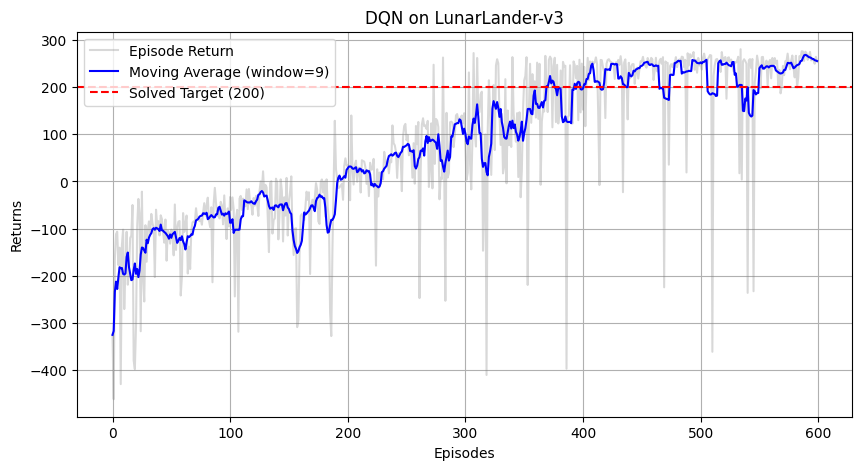

In [10]:
# Cell 6: 绘制训练曲线
def moving_average(a, window_size):
    """计算滑动平均，使曲线更平滑"""
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

episodes_list = list(range(len(return_list)))
mv_return = moving_average(return_list, 9)

plt.figure(figsize=(10, 5))
plt.plot(episodes_list, return_list, alpha=0.3, color='gray', label='Episode Return')
plt.plot(episodes_list, mv_return, color='blue', label='Moving Average (window=9)')
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('DQN on LunarLander-v3')
plt.axhline(200, color='red', linestyle='--', label='Solved Target (200)')
plt.legend()
plt.grid()
plt.show()